In [420]:
import os
import numpy as np

from src.config_presets.tools.get_config import get_config


config = get_config('Xerostomia_model')

src/config_presets/Base_config.yaml
src/config_presets/Xerostomia_model.yaml


In [421]:
patient_dir = "/home/macraedc/data/dataset_full_2mm_anonymized/10125"
CT = np.load(os.path.join(patient_dir, "ct.npy"))[0]
RTDOSE = np.load(os.path.join(patient_dir, "rtdose.npy"))[0]
RTSTRUCT = np.load(os.path.join(patient_dir, "segmentation_map.npy"))[0]



In [422]:
from scipy.ndimage import gaussian_filter

PET = np.zeros_like(CT)

# Get the center of the array
center = np.array(PET.shape) // 2

# Define sphere radius
radius = min(PET.shape) // 4  # adjust as needed

# Create a grid of coordinates
zz, yy, xx = np.ogrid[:PET.shape[0], :PET.shape[1], :PET.shape[2]]
distance = (zz - center[0])**2 + (yy - center[1])**2 + (xx - center[2])**2

# Set voxels inside the sphere to 40
PET[distance <= radius**2] = 40


PET = gaussian_filter(PET, sigma=10/2.355)  # FWHM=10, sigma=FWHM/2.355

In [423]:
ATTENTION = np.random.rand(*CT.shape)

In [432]:
row_dicts = [
    # {"ct": CT,
    #  #'attention' : ATTENTION,
    #  'Label': 'CT Image',
    # },
    # {"ct": CT,
    #  "pet": PET,
    #  'Label': 'PET Image',
    # },
    # {"rtdose": RTDOSE,
    #  'Label': 'RTDOSE',
    # },
    # # {"ct": CT,
    # #  "rtdose": RTDOSE,
    # #  'Label': 'CT + RTDOSE',
    # # },
    {"segmentation_map": RTSTRUCT / 17,
     'Label': 'binary RTSTRUCT',
    },
    {"segmentation_map": RTSTRUCT ,
     'Label': 'RTSTRUCT',
    },
    {"ct": CT,
     "segmentation_map": RTSTRUCT,
     'Label': 'CT + RTSTRUCT',
    },
    {"ct": CT,
     "segmentation_map": RTSTRUCT > 0,
     'Label': 'CT + binary RTSTRUCT',
    },
    {"rtdose": RTDOSE,
     "segmentation_map": RTSTRUCT ,
     'Label': 'CT + binary RTSTRUCT',
    },
]


slice_indexes = [30, 50, 70]

In [433]:
color_names = [
    'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown',
    'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'gold', 'deepskyblue',
    'crimson', 'lime', 'navy', 'magenta', 'darkorange'
]

In [ ]:
# PLOT
%load_ext autoreload
%autoreload 2
from src.visualization.plot_slices import plot_slices


config = get_config('Xerostomia_model')

fig, axes = plot_slices(
        config,
        row_dicts,
        slice_indexes,
        title=None,
        RT_region="HNC",
        plotting_axis="axial",
        verbose=False,
    )      

fig.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
src/config_presets/Base_config.yaml
src/config_presets/Xerostomia_model.yaml


In [ ]:
config['data']['preprocessing']['segmentation_map']['cmap']

['black', '', 'pink', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'gold', 'deepskyblue', 'crimson', 'lime', 'navy', 'magenta', 'darkorange']

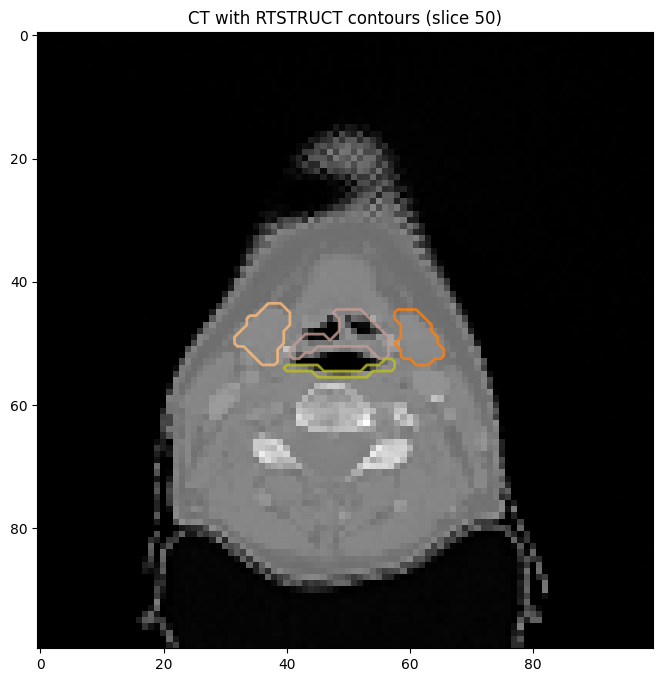

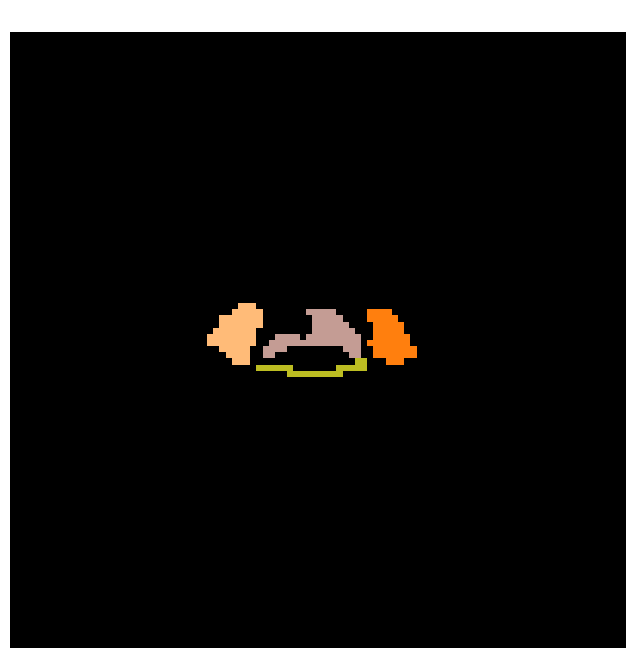

In [ ]:
from matplotlib import colors

import matplotlib.pyplot as plt

# Choose a slice index to visualize
slice_idx = 50

# Create a discrete colormap for RTSTRUCT labels 1-17
cmap = plt.get_cmap('tab20', 17)
norm = colors.BoundaryNorm(boundaries=np.arange(1, 19), ncolors=17)

fig, ax = plt.subplots(figsize=(8, 8))
# Show CT slice
ct_slice = CT[slice_idx]
im = ax.imshow(ct_slice, cmap='gray', interpolation='none')

# Overlay RTSTRUCT contours for labels 1-17
for label in range(1, 18):
    mask = RTSTRUCT[slice_idx] == label
    if np.any(mask):
        ax.contour(mask, levels=[0.5], colors=[cmap(norm(label))], linewidths=2, alpha=0.8)

ax.set_title(f"CT with RTSTRUCT contours (slice {slice_idx})")
plt.show()

# Flip the mask vertically to match the orientation of fig
fig2, ax2 = plt.subplots(figsize=(8, 8))
rtstruct_slice = RTSTRUCT[slice_idx]

# Create a colormap with black for background (0), then cmap for labels 1-17
colors_list = ['black'] + [cmap(norm(i)) for i in range(1, 18)]
custom_cmap = colors.ListedColormap(colors_list)
custom_norm = colors.BoundaryNorm(boundaries=np.arange(0, 19), ncolors=18)

ax2.imshow(rtstruct_slice, cmap=custom_cmap, norm=custom_norm, interpolation='none')

ax2.set_title(f"RTSTRUCT filled contours (slice {slice_idx})", color='white')
ax2.axis('off')
plt.show()